# Predict Experiment

Train LSTM forecast artifacts, build shared data, and write prediction diagnostics for the explicit run.


LSTM signals:   0%|          | 0/3 [00:00<?, ?signal/s]

wholesale_price models:   0%|          | 0/1 [00:00<?, ?model/s]

LSTM wholesale_price:   0%|          | 0/50 [00:00<?, ?epoch/s]

load models:   0%|          | 0/6 [00:00<?, ?model/s]

LSTM load/household/0:   0%|          | 0/20 [00:00<?, ?epoch/s]

...

,share_data_train_test,train_start_date,train_end_date,eval_start_date,eval_end_date,history_window,future_horizon,device,artifact_dir
0,"(2019, 2020)",2019-01-01,2019-12-31,2020-04-01,2020-04-15,192,49,cuda,D:\RL_Thesis_Project\MADRL_ESS\artifacts\runs\...


,signal,component,artifact_count
0,load,heatpump,3
1,load,household,3
2,pv,NaN,1
3,wholesale_price,NaN,1


,signal,agent_index,component,model_path,train_loss,val_loss,best_epoch,n_windows,val_windows,epochs,hidden_size,num_layers,dropout,lr,blend_weight,val_step1_mae,optimized_metric
0,wholesale_price,NaN,NaN,D:\RL_Thesis_Project\MADRL_ESS\artifacts\runs\...,0.254070,2.658244,18.0,24285,5207,50,128,2,0.1,0.0010,NaN,NaN,NaN
1,load,0.0,household,D:\RL_Thesis_Project\MADRL_ESS\artifacts\runs\...,17.453517,21.645101,7.0,24285,5207,20,64,2,0.1,0.0010,0.2,3.834185,mae_step1
2,load,1.0,household,D:\RL_Thesis_Project\MADRL_ESS\artifacts\runs\...,5.715041,5.916656,10.0,24285,5207,20,64,2,0.1,0.0010,0.1,3.543065,mae_step1
3,load,2.0,household,D:\RL_Thesis_Project\MADRL_ESS\artifacts\runs\...,4.615127,4.689712,7.0,24285,5207,20,64,2,0.1,0.0010,0.4,2.936129,mae_step1
4,load,0.0,heatpump,D:\RL_Thesis_Project\MADRL_ESS\artifacts\runs\...,778.144190,933.356618,10.0,24285,5207,20,64,2,0.1,0.0010,0.0,5.633226,blocked_bias_guard_step1
5,load,1.0,heatpump,D:\RL_Thesis_Project\MADRL_ESS\artifacts\runs\...,220.944447,248.983696,7.0,24285,5207,20,64,2,0.1,0.0010,0.0,4.420722,blocked_bias_guard_step1
6,load,2.0,heatpump,D:\RL_Thesis_Project\MADRL_ESS\artifacts\runs\...,0.442746,0.540852,20.0,24285,5207,20,64,2,0.1,0.0010,0.0,19.254616,blocked_bias_guard_step1
7,pv,NaN,NaN,D:\RL_Thesis_Project\MADRL_ESS\artifacts\runs\...,0.265007,0.220000,13.0,24288,5208,20,64,1,0.1,0.0008,NaN,NaN,NaN


,signal_name,series_name,row_count,rmse,mae,mape_pct
0,heatpump,SFH12,1440.0,12.714747,6.604068,912.036120
1,heatpump,SFH18,1440.0,12.800338,6.763919,748.785880
2,heatpump,SFH20,1440.0,12.268809,8.256923,1193.821669
3,load,SFH12,1440.0,16.125585,9.783938,116.945587
4,load,SFH18,1440.0,14.839851,9.014377,128.909840
5,load,SFH20,1440.0,14.411945,10.481165,103.278691
6,pv,shared_pv,1440.0,0.892393,0.433368,71.319464
7,wholesale_price,wholesale_price,1440.0,0.036826,0.027315,221.407061


,schema_version,pv_shared,train_episodes,eval_episodes,share_data_dir
0,2,True,362,15,D:\RL_Thesis_Project\MADRL_ESS\artifacts\runs\...


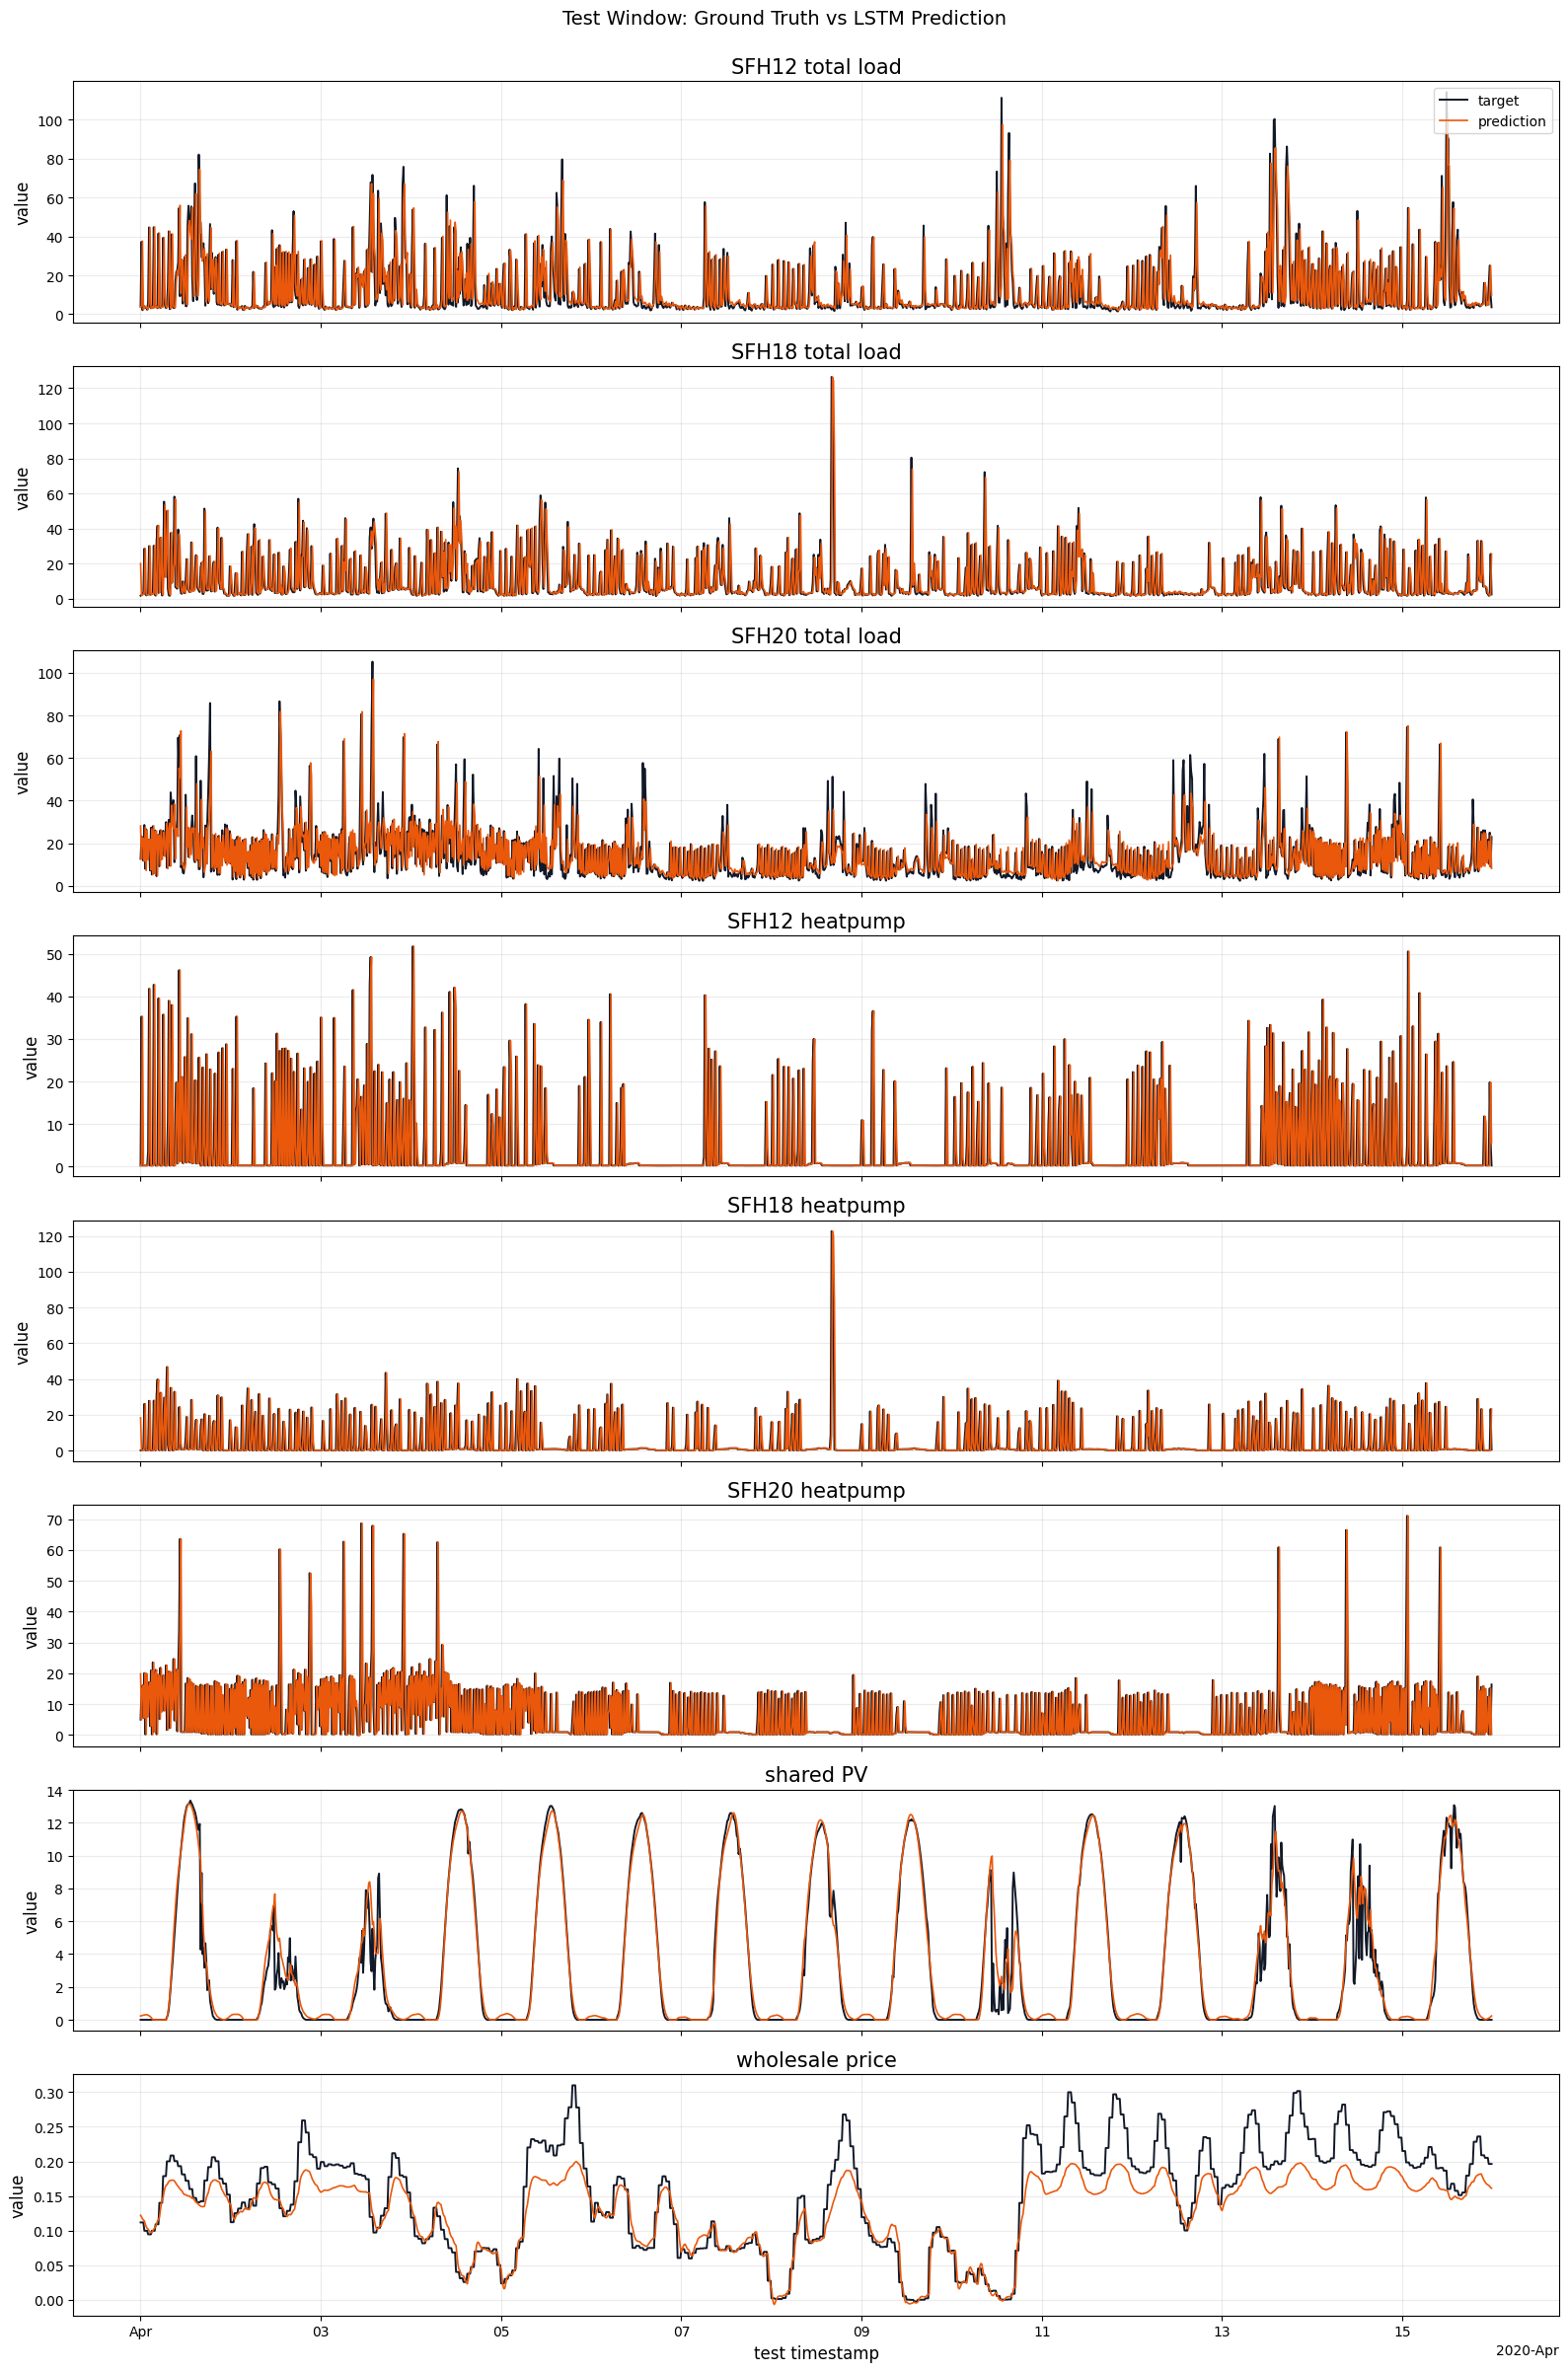

In [1]:
from pathlib import Path
from dataclasses import replace
import json
import os
import sys

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / 'configs' / 'cfg.py').exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from configs.cfg import Cfg
from data.share_data import build_share_data
from predictors.lstm_eval import write_test_outputs_from_share_data
from predictors.lstm_training import train_forecasters
from scripts.plot import plot_predict_results
from utils.run_artifacts import create_run_dir, write_config_json

cfg = Cfg()
run_dir = create_run_dir(cfg)
forecast = train_forecasters(cfg, run_dir, overwrite=True)
cfg = replace(cfg, forecast=replace(cfg.forecast, lstm_artifact_dir=str(forecast['artifact_dir'])))
write_config_json(cfg, run_dir)
share_data_dir = build_share_data(cfg, run_dir, forecast['artifact_dir'], overwrite=True)
test_outputs = write_test_outputs_from_share_data(cfg, share_data_dir, run_dir)
figures = plot_predict_results(run_dir)

config_snapshot = pd.DataFrame([{
    'share_data_train_test': cfg.data.share_data_train_test,
    'train_start_date': cfg.data.train_start_date,
    'train_end_date': cfg.data.train_end_date,
    'eval_start_date': cfg.data.eval_start_date,
    'eval_end_date': cfg.data.eval_end_date,
    'history_window': cfg.forecast.history_window,
    'future_horizon': cfg.obs.sequence_length,
    'device': cfg.runtime.device,
    'artifact_dir': str(forecast['artifact_dir']),
}])
train_summary = pd.read_csv(run_dir / 'forecast' / 'tables' / 'forecast_train_summary.csv')
artifact_table = train_summary.groupby(['signal', 'component'], dropna=False, as_index=False).agg(artifact_count=('model_path', 'nunique'))
manifest = json.loads((share_data_dir / 'manifest.json').read_text(encoding='utf-8'))
manifest_summary = pd.DataFrame([{
    'schema_version': manifest['schema_version'],
    'pv_shared': manifest['pv_shared'],
    'train_episodes': manifest['splits']['train']['n_episodes'],
    'eval_episodes': manifest['splits']['eval']['n_episodes'],
    'share_data_dir': str(share_data_dir),
}])

display(Markdown(f'## Predict Results\\nRun dir: `{run_dir}`  \\nShare data: `{share_data_dir}`'))
display(config_snapshot)
display(artifact_table)
display(train_summary)
display(test_outputs['metrics'])
display(manifest_summary)
for figure in figures.values():
    display(figure)
    plt.close(figure)
